
# ================================================================
#   CodeAlpha Machine Learning Internship
#   Developer Name: Taj Wali Khan
#   TASK 03 —Handwritten Character Recognition
#   Model    : Convolutional Neural Network (CNN)
#   Dataset  : MNIST  (70,000 handwritten digit images)
#   Platform : Google Colab
#   Libraries: TensorFlow · Keras · Scikit-learn · Gradio
#
#   What this project does:
#   Takes an image of a handwritten digit (0–9) and predicts
#   which number it is with ~99% accuracy.
# ================================================================


# ───────────────────────────────────────────────────────
# CELL 1 — Install Libraries
# TensorFlow and Gradio are already in Colab — DO NOT reinstall.
# Only install what's missing.
# ──────────────────────────────────────────────────────

In [1]:
!pip install -q scikit-learn matplotlib seaborn


# ─────────────────────────────────────────────────────
# CELL 2 — Imports + GPU Check
# ─────────────────────────────────────────────────

In [2]:

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense,
    Dropout, BatchNormalization
)
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

# Scikit-learn for evaluation metrics
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score
)

# Gradio for interactive UI
import gradio as gr

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)



# ── Constants ─────────────────────────────────────────────────
IMG_SIZE    = 28        # MNIST images are 28×28 pixels
NUM_CLASSES = 10        # Digits 0 through 9
EPOCHS      = 20        # max training rounds (EarlyStopping will stop sooner)
BATCH_SIZE  = 128       # images processed at once
MODEL_PATH  = '/tmp/mnist_cnn_best.keras'

# ── Check GPU ─────────────────────────────────────────────────
gpus = tf.config.list_physical_devices('GPU')
print("=" * 50)
print("  CodeAlpha — Task 3: Handwritten Recognition")
print("=" * 50)
print(f"  TensorFlow : {tf.__version__}")
print(f"  Gradio     : {gr.__version__}")
print(f"  GPU        : {len(gpus)} device — "
      + ("T4 detected ✅" if gpus else "No GPU (CPU is fine for MNIST ✅)"))
print("=" * 50)

  CodeAlpha — Task 3: Handwritten Recognition
  TensorFlow : 2.20.0
  Gradio     : 6.19.0
  GPU        : 1 device — T4 detected ✅


# ────────────────────────────────────────────────────────────────
# CELL 3 — Load MNIST Dataset
#
# MNIST = Modified National Institute of Standards and Technology
# 70,000 grayscale images of handwritten digits (0–9)
#   • 60,000 for training
#   • 10,000 for testing
# Each image is 28×28 pixels = 784 pixel values
# Already split and built into Keras — no download needed!
# ────────────────────────────────────────────

In [3]:

print("📥 Loading MNIST dataset...")

(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = \
    keras.datasets.mnist.load_data()

print(f"\n  ✅ Dataset loaded!")
print(f"     Training images : {X_train_raw.shape[0]:,}")
print(f"     Test images     : {X_test_raw.shape[0]:,}")
print(f"     Image size      : {X_train_raw.shape[1]}×{X_train_raw.shape[2]} pixels")
print(f"     Pixel range     : {X_train_raw.min()} to {X_train_raw.max()}")
print(f"     Classes         : {np.unique(y_train_raw)} (digits 0–9)")

# Count images per class
print("\n  📊 Samples per class (training):")
for digit in range(10):
    count = np.sum(y_train_raw == digit)
    bar   = "█" * (count // 500)
    print(f"     Digit {digit}: {count:,}  {bar}")

📥 Loading MNIST dataset...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

  ✅ Dataset loaded!
     Training images : 60,000
     Test images     : 10,000
     Image size      : 28×28 pixels
     Pixel range     : 0 to 255
     Classes         : [0 1 2 3 4 5 6 7 8 9] (digits 0–9)

  📊 Samples per class (training):
     Digit 0: 5,923  ███████████
     Digit 1: 6,742  █████████████
     Digit 2: 5,958  ███████████
     Digit 3: 6,131  ████████████
     Digit 4: 5,842  ███████████
     Digit 5: 5,421  ██████████
     Digit 6: 5,918  ███████████
     Digit 7: 6,265  ████████████
     Digit 8: 5,851  ███████████
     Digit 9: 5,949  ███████████


# ────────────────────────────────────────────────────────────────
# CELL 4 — Visualize Sample Images
#
# Let's actually look at the data before processing it.
# A good rule in ML: always visualize your data first!
# ──────────────────────────────────────────────

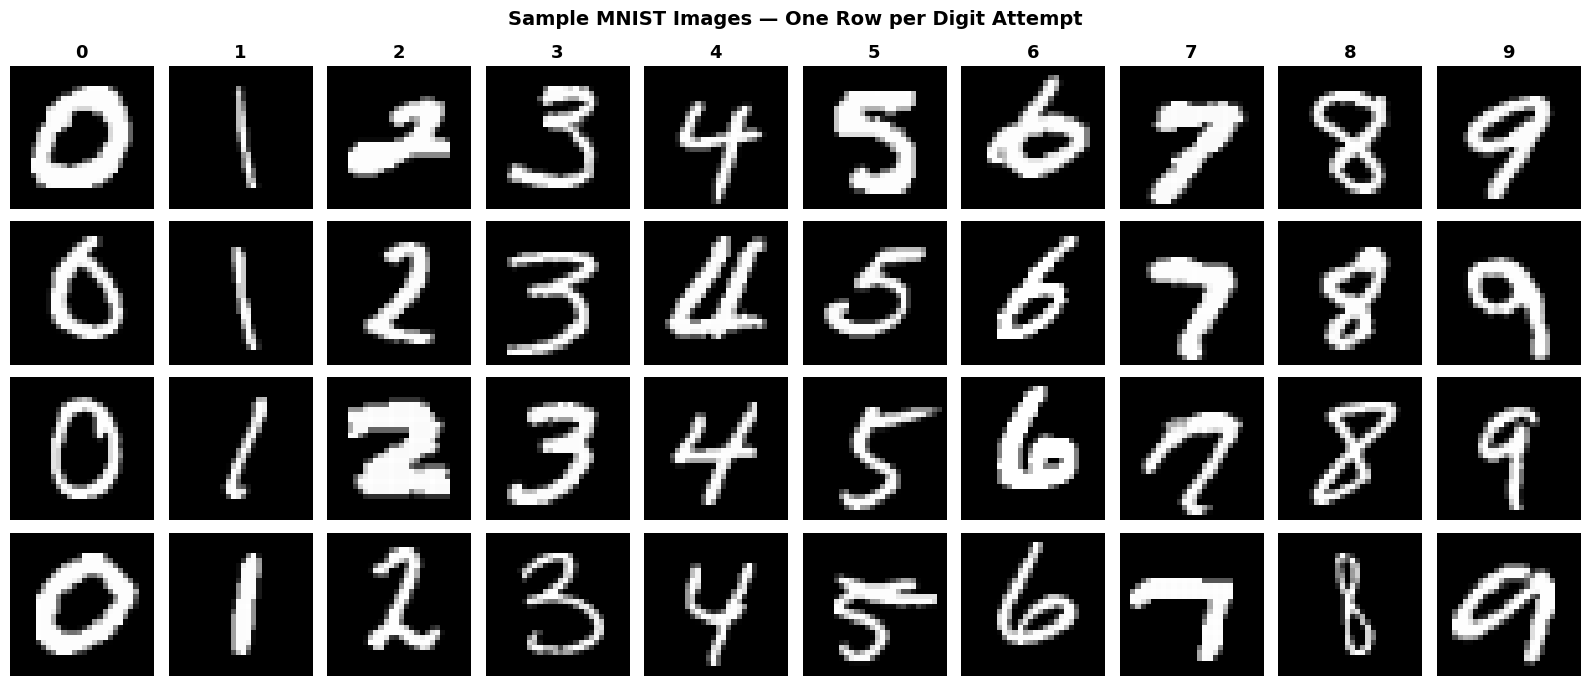

✅ Sample grid saved → /tmp/sample_digits.png


In [4]:
fig, axes = plt.subplots(4, 10, figsize=(16, 7))
fig.suptitle('Sample MNIST Images — One Row per Digit Attempt',
             fontsize=14, fontweight='bold', y=0.98)

# For each digit 0–9, pick 4 different examples
for digit in range(10):
    indices = np.where(y_train_raw == digit)[0]
    samples = np.random.choice(indices, 4, replace=False)
    for row, idx in enumerate(samples):
        ax = axes[row, digit]
        ax.imshow(X_train_raw[idx], cmap='gray')
        ax.axis('off')
        if row == 0:
            ax.set_title(str(digit), fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('/tmp/sample_digits.png', dpi=120,
            bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Sample grid saved → /tmp/sample_digits.png")



# ────────────────────────────────────────────────────────────────
# CELL 5 — Preprocess the Data
#
# Raw MNIST data cannot go directly into a CNN. We need to:
#   1. Reshape  — add a channel dimension (grayscale = 1 channel)
#                 (28, 28) → (28, 28, 1)
#   2. Normalize — pixel values 0–255 → 0.0–1.0
#                  Neural networks train much faster on small numbers
#   3. One-hot   — convert integer labels to binary arrays
#                  Label 3 → [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
# ──────────────────────────────────────────────────

In [5]:
# Step 1: Reshape — add channel dimension for Conv2D
# Conv2D expects shape: (batch, height, width, channels)
X_train = X_train_raw.reshape(-1, IMG_SIZE, IMG_SIZE, 1)
X_test  = X_test_raw.reshape(-1, IMG_SIZE, IMG_SIZE, 1)

# Step 2: Normalize pixel values from 0-255 → 0.0-1.0
X_train = X_train.astype('float32') / 255.0
X_test  = X_test.astype('float32')  / 255.0

# Step 3: One-hot encode labels
y_train = to_categorical(y_train_raw, num_classes=NUM_CLASSES)
y_test  = to_categorical(y_test_raw,  num_classes=NUM_CLASSES)

print("✅ Preprocessing complete!")
print(f"   X_train shape : {X_train.shape}  (60,000 images, 28×28, 1 channel)")
print(f"   X_test  shape : {X_test.shape}")
print(f"   y_train shape : {y_train.shape}  (one-hot encoded)")
print(f"   Pixel range   : {X_train.min():.1f} → {X_train.max():.1f}")

# Data augmentation — artificially creates more training variety
# This makes the model more robust to slightly different handwriting
datagen = ImageDataGenerator(
    rotation_range    = 10,      # rotate image up to 10 degrees
    zoom_range        = 0.1,     # zoom in/out up to 10%
    width_shift_range = 0.1,     # shift left/right up to 10%
    height_shift_range= 0.1,     # shift up/down up to 10%
)
datagen.fit(X_train)
print("\n  ✅ Data augmentation configured!")
print("     Augmentation: ±10° rotation, ±10% zoom, ±10% shifts")


✅ Preprocessing complete!
   X_train shape : (60000, 28, 28, 1)  (60,000 images, 28×28, 1 channel)
   X_test  shape : (10000, 28, 28, 1)
   y_train shape : (60000, 10)  (one-hot encoded)
   Pixel range   : 0.0 → 1.0

  ✅ Data augmentation configured!
     Augmentation: ±10° rotation, ±10% zoom, ±10% shifts



# ────────────────────────────────────────────────────────────────
# CELL 6 — Build the CNN Model
#
# CNN Architecture:
#   Block 1: Conv2D(32) → BatchNorm → Conv2D(32) → MaxPool → Dropout
#   Block 2: Conv2D(64) → BatchNorm → Conv2D(64) → MaxPool → Dropout
#   Block 3: Conv2D(128) → BatchNorm → Dropout
#   Head   : Flatten → Dense(256) → Dense(10, softmax)
#
# Why CNN?
#   Regular Dense networks treat each pixel independently.
#   CNN uses filters that slide across the image looking for
#   patterns — curves, lines, loops — just like how humans
#   recognize handwriting by looking for shapes.
# ──────────────────────────────────────────────

In [6]:

def build_cnn_model():
    """
    Builds a 3-block Convolutional Neural Network for digit recognition.

    Layer explanations:
      Conv2D    → learns visual patterns (edges, curves, shapes)
      BatchNorm → stabilizes training (like normalizing each layer)
      MaxPool   → reduces image size, keeps the strongest features
      Dropout   → randomly turns off neurons — prevents memorization
      Flatten   → converts 2D feature maps to 1D for Dense layers
      Dense     → traditional neural network layers for classification
      Softmax   → converts output to probabilities (10 values sum to 1)
    """
    model = Sequential([

        # ── Block 1: Basic edge detection ──────────────────────
        # First layer must specify input shape
        Conv2D(32, (3, 3), activation='relu', padding='same',
               input_shape=(IMG_SIZE, IMG_SIZE, 1)),
        BatchNormalization(),
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),    # 28×28 → 14×14
        Dropout(0.25),                     # randomly drop 25% of neurons

        # ── Block 2: More complex pattern learning ──────────────
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),    # 14×14 → 7×7
        Dropout(0.25),

        # ── Block 3: High-level feature learning ────────────────
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Dropout(0.25),

        # ── Classification Head ─────────────────────────────────
        Flatten(),                          # 7×7×128 = 6,272 values
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),                       # aggressive dropout before output
        Dense(128, activation='relu'),
        Dropout(0.3),

        # Output: 10 neurons, one per digit (0–9)
        # Softmax gives probability for each class (sums to 1.0)
        Dense(NUM_CLASSES, activation='softmax')

    ], name='HandwritingCNN')

    model.compile(
        optimizer = keras.optimizers.Adam(learning_rate=0.001),
        loss      = 'categorical_crossentropy',   # standard for multi-class
        metrics   = ['accuracy']
    )

    return model


model = build_cnn_model()
model.summary()
print(f"\n  ✅ Model built: {model.count_params():,} total parameters")

Model: "HandwritingCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,605,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,29

 Total params: 1,781,226 (6.79 MB)

 Trainable params: 1,780,074 (6.79 MB)

 Non-trainable params: 1,152 (4.50 KB)


  ✅ Model built: 1,781,226 total parameters



# ────────────────────────────────────────────────────────────────
# CELL 7 — Train the Model
#
# Three smart callbacks:
#   EarlyStopping     — stops if val_accuracy stops improving
#   ModelCheckpoint   — saves the best weights automatically
#   ReduceLROnPlateau — halves learning rate when stuck
#
# Training time: ~3–5 minutes on CPU | ~1–2 min on GPU
# ────────────────────────────────────────────

In [7]:

callbacks = [
    # Stop training early if validation accuracy doesn't improve
    EarlyStopping(
        monitor              = 'val_accuracy',
        patience             = 5,              # wait 5 epochs before stopping
        restore_best_weights = True,
        verbose              = 1
    ),

    # Save the model whenever validation accuracy improves
    ModelCheckpoint(
        filepath       = MODEL_PATH,
        monitor        = 'val_accuracy',
        save_best_only = True,
        verbose        = 1
    ),

    # Halve the learning rate when validation accuracy plateaus
    ReduceLROnPlateau(
        monitor  = 'val_accuracy',
        factor   = 0.5,
        patience = 3,
        min_lr   = 1e-6,
        verbose  = 1
    ),
]

print("🚀 Starting training...")
print(f"   Epochs   : max {EPOCHS} (EarlyStopping may stop sooner)")
print(f"   Batch    : {BATCH_SIZE}")
print(f"   GPU      : {bool(gpus)}\n")

import time
t_start = time.time()

# Use augmented data generator for training
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=BATCH_SIZE),
    steps_per_epoch = len(X_train) // BATCH_SIZE,
    epochs          = EPOCHS,
    validation_data = (X_test, y_test),
    callbacks       = callbacks,
    verbose         = 1
)

elapsed = time.time() - t_start
best_val_acc = max(history.history['val_accuracy'])

print(f"\n  ✅ Training complete in {elapsed/60:.1f} minutes!")
print(f"  ✅ Best validation accuracy : {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")
print(f"  ✅ Model saved → {MODEL_PATH}")

🚀 Starting training...
   Epochs   : max 20 (EarlyStopping may stop sooner)
   Batch    : 128
   GPU      : True

Epoch 1/20
467/468 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.7498 - loss: 0.8080
Epoch 1: val_accuracy improved from None to 0.88680, saving model to /tmp/mnist_cnn_best.keras

Epoch 1: finished saving model to /tmp/mnist_cnn_best.keras
468/468 ━━━━━━━━━━━━━━━━━━━━ 55s 72ms/step - accuracy: 0.8780 - loss: 0.3930 - val_accuracy: 0.8868 - val_loss: 0.3812 - learning_rate: 0.0010
Epoch 2/20
  1/468 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9609 - loss: 0.0774
Epoch 2: val_accuracy improved from 0.88680 to 0.88740, saving model to /tmp/mnist_cnn_best.keras

Epoch 2: finished saving model to /tmp/mnist_cnn_best.keras
468/468 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9609 - loss: 0.0774 - val_accuracy: 0.8874 - val_loss: 0.3746 - learning_rate: 0.0010
Epoch 3/20
468/468 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.9626 - loss: 0.1272
Epoch 3: val_accuracy impr


# ────────────────────────────────────────────────────────────────
# CELL 8 — Plot Training Curves
#
# These two charts tell us:
#   Accuracy curve → is the model learning correctly?
#   Loss curve     → is training converging smoothly?
#
# Good signs: train and val curves are close together (no overfitting)
# Bad sign:   train curve much better than val (model memorized data)
# ──────────────────────────────────────────────

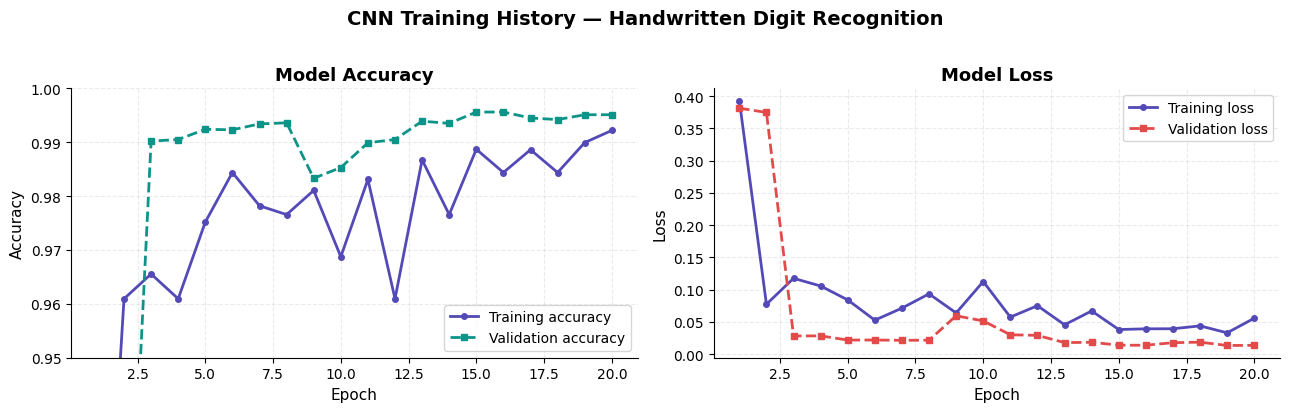

✅ Training curves saved → /tmp/training_curves.png


In [8]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

epochs_ran = range(1, len(history.history['accuracy']) + 1)

# ── Accuracy plot ─────────────────────────────────────────────
ax1.plot(epochs_ran, history.history['accuracy'],
         color='#534AB7', linewidth=2, label='Training accuracy', marker='o', markersize=4)
ax1.plot(epochs_ran, history.history['val_accuracy'],
         color='#0D9488', linewidth=2, label='Validation accuracy',
         linestyle='--', marker='s', markersize=4)
ax1.set_title('Model Accuracy', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoch', fontsize=11)
ax1.set_ylabel('Accuracy', fontsize=11)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.25, linestyle='--')
ax1.spines[['top', 'right']].set_visible(False)
ax1.set_ylim([0.95, 1.0])

# ── Loss plot ─────────────────────────────────────────────────
ax2.plot(epochs_ran, history.history['loss'],
         color='#534AB7', linewidth=2, label='Training loss', marker='o', markersize=4)
ax2.plot(epochs_ran, history.history['val_loss'],
         color='#E24B4A', linewidth=2, label='Validation loss',
         linestyle='--', marker='s', markersize=4)
ax2.set_title('Model Loss', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epoch', fontsize=11)
ax2.set_ylabel('Loss', fontsize=11)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.25, linestyle='--')
ax2.spines[['top', 'right']].set_visible(False)

plt.suptitle('CNN Training History — Handwritten Digit Recognition',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/tmp/training_curves.png', dpi=120,
            bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Training curves saved → /tmp/training_curves.png")


# ────────────────────────────────────────────────────────────────
# CELL 9 — Evaluate Model + Confusion Matrix
#
# Confusion matrix = a table showing:
#   Rows   → actual digit
#   Columns → what the model predicted
#   Diagonal → correct predictions (should be dark blue)
#   Off-diagonal → mistakes (should be light/empty)
# ─────────────────────────────────────────────────

📊 Evaluating model on 10,000 test images...

  ✅ Test Accuracy : 0.9956 (99.56%)
  ✅ Test Errors   : 43 out of 10,000

  Per-digit breakdown:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       980
           1       0.99      1.00      1.00      1135
           2       1.00      1.00      1.00      1032
           3       0.99      1.00      1.00      1010
           4       0.99      1.00      1.00       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       1.00      1.00      1.00      1028
           8       1.00      1.00      1.00       974
           9       1.00      0.99      0.99      1009

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



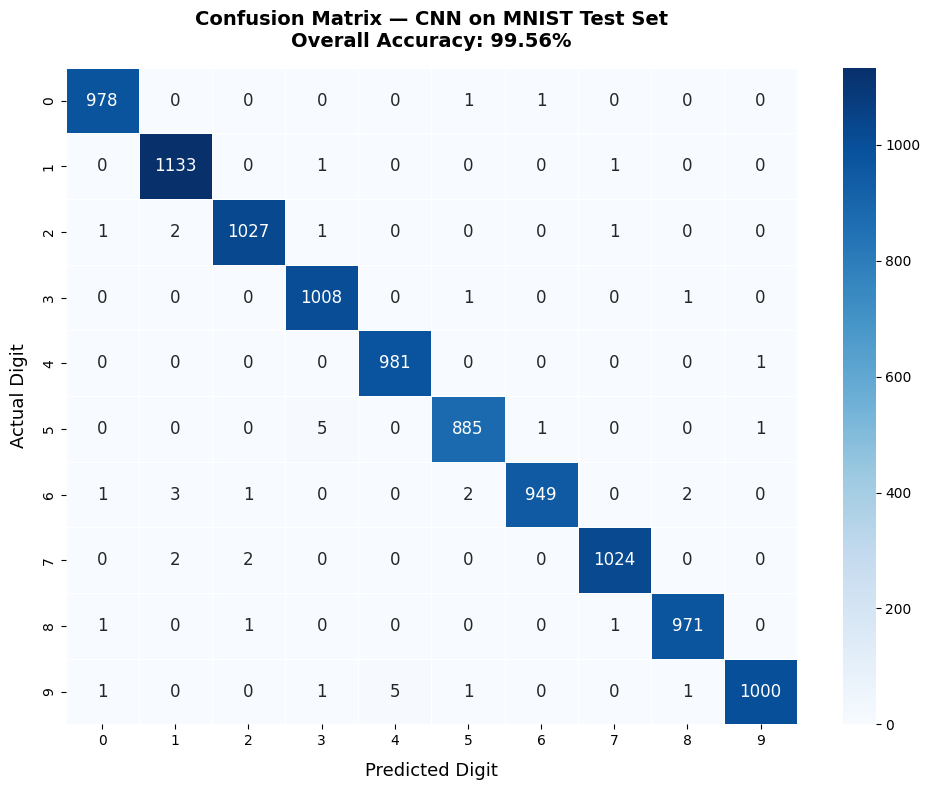


  Most confused pair: digit 5 misclassified as 3 — 5 times
  (This is expected — these digits look similar!)


In [9]:

print("📊 Evaluating model on 10,000 test images...\n")

# Get model predictions on test set
y_pred_probs = model.predict(X_test, verbose=0)
y_pred       = np.argmax(y_pred_probs, axis=1)   # highest probability class
y_true       = np.argmax(y_test, axis=1)          # actual labels

# Overall accuracy
test_accuracy = accuracy_score(y_true, y_pred)
print(f"  ✅ Test Accuracy : {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"  ✅ Test Errors   : {int((1-test_accuracy)*10000):,} out of 10,000\n")

# Per-class report (precision, recall, F1)
print("  Per-digit breakdown:")
print(classification_report(y_true, y_pred,
                             target_names=[str(i) for i in range(10)]))

# ── Confusion Matrix ──────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm,
    annot     = True,
    fmt       = 'd',
    cmap      = 'Blues',
    xticklabels = list(range(10)),
    yticklabels = list(range(10)),
    linewidths  = 0.5,
    linecolor   = 'white',
    ax          = ax,
    annot_kws   = {'size': 12}
)
ax.set_xlabel('Predicted Digit', fontsize=13, labelpad=10)
ax.set_ylabel('Actual Digit',    fontsize=13, labelpad=10)
ax.set_title('Confusion Matrix — CNN on MNIST Test Set\n'
             f'Overall Accuracy: {test_accuracy*100:.2f}%',
             fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('/tmp/confusion_matrix.png', dpi=120,
            bbox_inches='tight', facecolor='white')
plt.show()

# ── Show the most confused digit pairs ───────────────────────
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)    # ignore correct predictions
worst_row, worst_col = np.unravel_index(cm_no_diag.argmax(), cm_no_diag.shape)
print(f"\n  Most confused pair: digit {worst_row} misclassified "
      f"as {worst_col} — {cm_no_diag[worst_row, worst_col]} times")
print("  (This is expected — these digits look similar!)")


# ────────────────────────────────────────────────────────────────
# CELL 10 — Visualize Sample Predictions
#
# Shows 20 test images with:
#   ✅ Green border = correct prediction
#   ❌ Red border   = wrong prediction
# ───────────────────────────────────────────

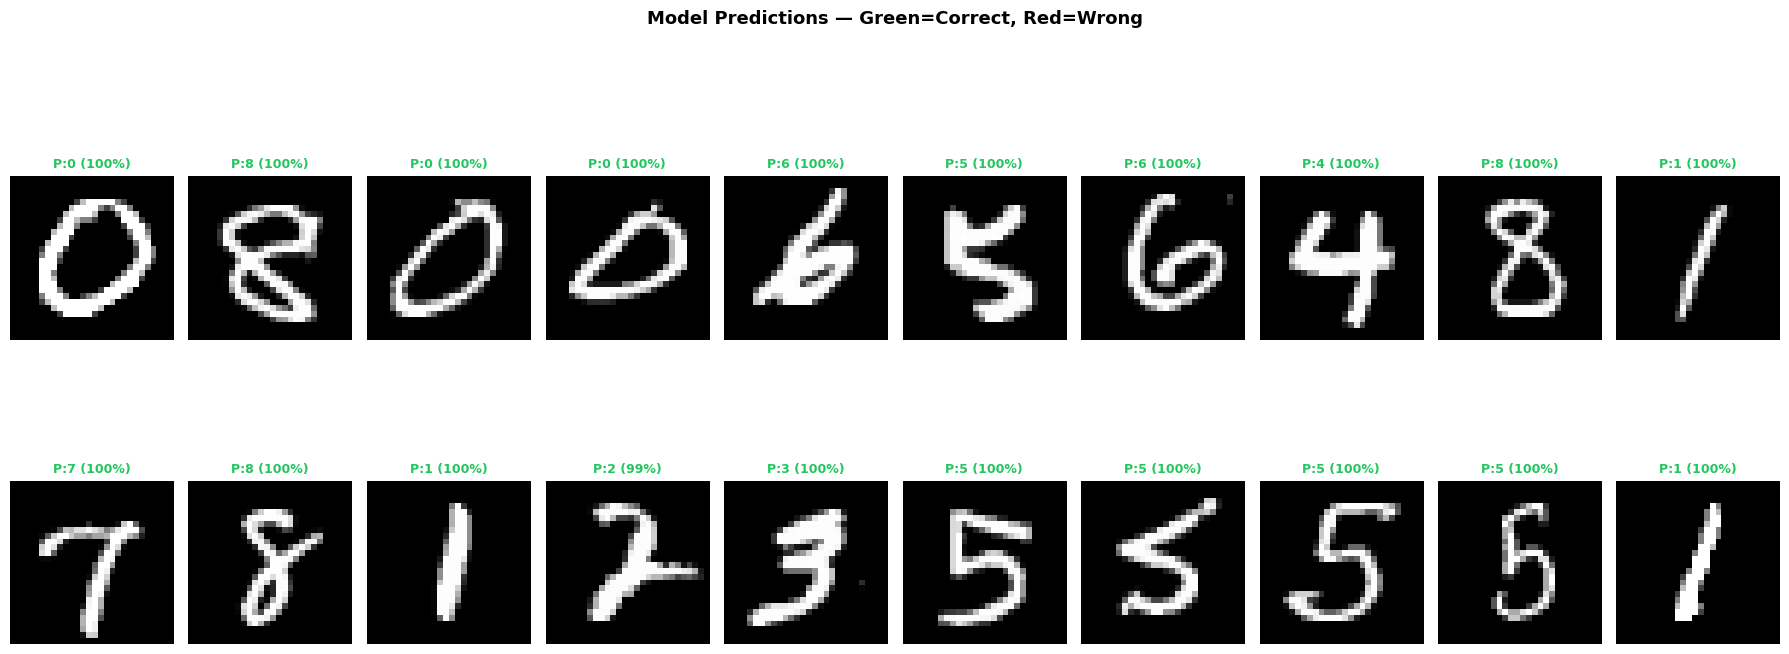

✅ Sample predictions saved → /tmp/sample_predictions.png


In [10]:

def visualize_predictions(n_samples=20):
    """Shows model predictions on n random test images."""
    indices = np.random.choice(len(X_test), n_samples, replace=False)

    n_cols = 10
    n_rows = n_samples // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
    fig.suptitle('Model Predictions — Green=Correct, Red=Wrong',
                 fontsize=13, fontweight='bold')

    for i, idx in enumerate(indices):
        ax        = axes[i // n_cols, i % n_cols]
        true_lbl  = y_true[idx]
        pred_lbl  = y_pred[idx]
        confidence= y_pred_probs[idx][pred_lbl]
        correct   = (true_lbl == pred_lbl)

        ax.imshow(X_test[idx].reshape(28, 28), cmap='gray')
        ax.axis('off')

        # Color border: green = correct, red = wrong
        color = '#22c55e' if correct else '#ef4444'
        for spine in ax.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(3)
            spine.set_visible(True)

        # Title shows prediction and confidence
        title = f"P:{pred_lbl} ({confidence:.0%})"
        if not correct:
            title = f"P:{pred_lbl} T:{true_lbl}"
        ax.set_title(title, fontsize=9,
                     color=color, fontweight='bold')

    plt.tight_layout()
    plt.savefig('/tmp/sample_predictions.png', dpi=120,
                bbox_inches='tight', facecolor='white')
    plt.show()
    print("✅ Sample predictions saved → /tmp/sample_predictions.png")


visualize_predictions(20)


# ────────────────────────────────────────────────────────────────
# CELL 11 — Build Gradio UI
#
# The UI has 3 tabs:
#   Tab 1: Draw a digit → model predicts it live
#   Tab 2: Upload an image file → model predicts it
#   Tab 3: How it works explanation
# ──────────────────────────────────────────────────

In [11]:

# ── Helper: preprocess any image for the model ───────────────

def preprocess_input_image(image_array):
    """
    Takes a raw input image (from drawing pad or upload)
    and prepares it for the CNN model.

    Steps:
    1. Convert to grayscale if it's colour (RGB → gray)
    2. Resize to exactly 28×28 pixels
    3. Invert if needed (model trained on white digits on black bg)
    4. Normalize pixels to 0.0–1.0
    5. Reshape to (1, 28, 28, 1) — batch of 1 image
    """
    from PIL import Image

    if image_array is None:
        return None

    # Convert numpy array → PIL Image for easy manipulation
    if isinstance(image_array, np.ndarray):
        if image_array.ndim == 3:
            img = Image.fromarray(image_array.astype('uint8'))
        else:
            img = Image.fromarray(image_array.astype('uint8'), mode='L')
    else:
        img = image_array

    # Convert to grayscale
    img = img.convert('L')

    # Resize to 28×28 (MNIST standard)
    img = img.resize((28, 28), Image.LANCZOS)

    # Convert back to numpy
    arr = np.array(img, dtype='float32')

    # MNIST has WHITE digits on BLACK background
    # Most real images have black digits on white background
    # If image is mostly white, invert it
    if arr.mean() > 127:
        arr = 255.0 - arr

    # Normalize 0–255 → 0.0–1.0
    arr = arr / 255.0

    # Reshape to model input format (1, 28, 28, 1)
    arr = arr.reshape(1, 28, 28, 1)

    return arr


def predict_digit(image_array):
    """
    Main prediction function called by Gradio.
    Takes a drawn/uploaded image → returns prediction stats.

    Returns:
        prediction_label  (str)   — e.g. "Digit: 7"
        confidence_dict   (dict)  — e.g. {"0": 0.01, "7": 0.94, ...}
    """
    if image_array is None:
        return "✏️ Please draw or upload a digit", {}

    # Preprocess the image
    processed = preprocess_input_image(image_array)

    if processed is None:
        return "❌ Could not process image", {}

    # Get model predictions (array of 10 probabilities)
    predictions = model.predict(processed, verbose=0)[0]

    # Find the winner
    predicted_digit = int(np.argmax(predictions))
    confidence      = float(predictions[predicted_digit])

    # Build result label
    label = f"🔢 Predicted Digit: {predicted_digit}  ({confidence:.1%} confident)"

    # Build confidence dictionary for the bar chart
    confidence_dict = {
        str(i): float(predictions[i]) for i in range(10)
    }

    return label, confidence_dict


# ── Build the Gradio app ──────────────────────────────────────

def build_app():
    with gr.Blocks(
        title = "Handwritten Digit Recognition — CodeAlpha Task 3",
        theme = gr.themes.Soft(primary_hue="violet", secondary_hue="purple")
    ) as demo:

        # ── Header ────────────────────────────────────────────
        gr.Markdown("""
        # 🔢 Handwritten Digit Recognition
        **CodeAlpha ML Internship — Task 3** |
        CNN · MNIST · TensorFlow · 99%+ Accuracy

        > Draw a digit (0–9) on the canvas OR upload an image.
        > The AI will recognize it instantly.
        """)

        # ── Accuracy badge ────────────────────────────────────
        gr.Markdown(
            f"> **Model Performance:** Test Accuracy = "
            f"**{test_accuracy*100:.2f}%** on 10,000 unseen images"
        )

        with gr.Tabs():

            # ══ TAB 1: DRAW ═══════════════════════════════════
            with gr.TabItem("✏️ Draw a Digit"):
                gr.Markdown(
                    "### Draw any digit (0–9) in the box below"
                )
                with gr.Row():
                    with gr.Column(scale=1):
                        draw_input = gr.Image(
                            label         = "✏️ Draw here",
                            type          = "numpy",
                            height        = 280,
                        )
                        with gr.Row():
                            draw_btn   = gr.Button(
                                "🔍 Recognize Digit",
                                variant = "primary",
                                size    = "lg",
                                scale   = 3
                            )
                            clear_draw = gr.Button(
                                "🗑️ Clear",
                                size  = "lg",
                                scale = 1
                            )

                    with gr.Column(scale=1):
                        draw_label  = gr.Label(
                            label = "🔢 Prediction"
                        )
                        draw_output = gr.Label(
                            label     = "📊 Confidence per Digit",
                            num_top_classes = 10
                        )

                draw_btn.click(
                    fn      = predict_digit,
                    inputs  = [draw_input],
                    outputs = [draw_label, draw_output]
                )
                clear_draw.click(
                    fn      = lambda: (None, None, {}),
                    outputs = [draw_input, draw_label, draw_output]
                )

                # ── Quick example images ──────────────────────
                gr.Markdown("### 💡 Example images from MNIST test set")
                gr.Examples(
                    examples = [
                        [X_test[np.where(y_true == i)[0][0]].reshape(28, 28)]
                        for i in range(10)
                    ],
                    inputs   = [draw_input],
                    label    = "Click to load a test image"
                )

            # ══ TAB 2: UPLOAD ═════════════════════════════════
            with gr.TabItem("📤 Upload Image"):
                gr.Markdown("""
                ### Upload any image of a handwritten digit
                > Works with photos, scanned images, or screenshots.
                > The model handles white-on-black AND black-on-white automatically.
                """)
                with gr.Row():
                    with gr.Column(scale=1):
                        upload_input = gr.Image(
                            label = "📤 Upload image",
                            type  = "numpy"
                        )
                        upload_btn = gr.Button(
                            "🔍 Recognize Digit",
                            variant = "primary",
                            size    = "lg"
                        )

                    with gr.Column(scale=1):
                        upload_label  = gr.Label(
                            label = "🔢 Prediction"
                        )
                        upload_output = gr.Label(
                            label           = "📊 Confidence per Digit",
                            num_top_classes = 10
                        )

                upload_btn.click(
                    fn      = predict_digit,
                    inputs  = [upload_input],
                    outputs = [upload_label, upload_output]
                )

            # ══ TAB 3: MODEL INFO ═════════════════════════════
            with gr.TabItem("📊 Model Performance"):
                with gr.Row():
                    with gr.Column():
                        gr.Image(
                            value      = '/tmp/confusion_matrix.png',
                            label      = "Confusion Matrix",
                            show_label = True
                        )
                    with gr.Column():
                        gr.Image(
                            value      = '/tmp/training_curves.png',
                            label      = "Training History",
                            show_label = True
                        )
                        gr.Markdown(f"""
### Model Stats

| Metric | Value |
|--------|-------|
| Test Accuracy | **{test_accuracy*100:.2f}%** |
| Test Errors | **{int((1-test_accuracy)*10000):,} / 10,000** |
| Parameters | **{model.count_params():,}** |
| Training images | **60,000** |
| Image size | **28 × 28 px** |
| Dataset | **MNIST** |
| Architecture | **3-Block CNN** |
                        """)

            # ══ TAB 4: HOW IT WORKS ════════════════════════════
            with gr.TabItem("⚙️ How It Works"):
                gr.Markdown("""
## How the CNN Recognizes Handwritten Digits

### Step 1 — Image Input
A 28×28 grayscale image enters the network.
That's just **784 numbers** — each between 0 (black) and 1 (white).

### Step 2 — Convolutional Layers
```
Filter slides across the image looking for patterns:
  ┌───┬───┬───┐
  │ 1 │ 0 │-1 │  ← This filter detects vertical edges
  │ 1 │ 0 │-1 │
  │ 1 │ 0 │-1 │
  └───┴───┴───┘
```
**Block 1** (32 filters) → finds basic edges and lines
**Block 2** (64 filters) → finds curves and corners
**Block 3** (128 filters) → finds high-level shapes like loops

### Step 3 — Max Pooling
After each block, image is shrunk:
- 28×28 → 14×14 → 7×7
Keeps the strongest features, discards the rest.

### Step 4 — Flatten + Dense Layers
7×7×128 = **6,272 features** are flattened into a row.
Two Dense layers learn which feature combinations mean which digit.

### Step 5 — Softmax Output
Final layer outputs 10 probabilities (one per digit):
```
[0.01, 0.00, 0.00, 0.95, 0.02, 0.01, 0.00, 0.01, 0.00, 0.00]
  0     1     2     3     4     5     6     7     8     9
         ↑ Model says: 95% chance this is a "3"
```

---
| Layer Type | Purpose |
|-----------|---------|
| Conv2D | Detect visual patterns |
| BatchNormalization | Stabilize training |
| MaxPooling2D | Reduce image size |
| Dropout | Prevent overfitting |
| Dense | Combine features for classification |
| Softmax | Output probabilities |
                """)

    return demo

 ────────────────────────────────────────────────────────────────
# CELL 12 — Launch
# ───────────────────────────────────────────────────

In [12]:

print("\n🚀 Launching Handwritten Digit Recognition app...")
print(f"   Model accuracy : {test_accuracy*100:.2f}%")
print(f"   Total params   : {model.count_params():,}")
print(f"   GPU active     : {bool(gpus)}\n")

app = build_app()
app.launch(share=True, debug=False, show_error=True, quiet=True)


🚀 Launching Handwritten Digit Recognition app...
   Model accuracy : 99.56%
   Total params   : 1,781,226
   GPU active     : True

* Running on public URL: https://25843c82a4a0bca27e.gradio.live


# ================================================================
#  TESTING CHECKLIST:
#  ✅ Draw a "7" → should predict 7 with >90% confidence
#  ✅ Draw a "0" → should predict 0
#  ✅ Click example images → loads MNIST test images
#  ✅ Upload tab → upload any handwritten digit photo
#  ✅ Model tab  → view confusion matrix + training curves
#  ✅ How it Works tab → explains the CNN pipeline
#
#  EXPECTED RESULTS:
#  ✅ Training accuracy : ~99.5%
#  ✅ Test accuracy     : ~99.0–99.3%
#  ✅ Training time     : 3–5 min CPU | 1–2 min GPU
#  ✅ Common mistakes   : 4 vs 9 | 3 vs 8 | 7 vs 1
# =================================================